# 🎥 Video 06: Drug-Likeness Rules & MedChem Filters
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 2 (Topic 09: Lipinski's Rule of 5) & LEVEL 4 (Topic 23: MedChem Filters)
* **Target Audience:** Cheminformatics Engineers, Medicinal Chemists, Screening Scientists

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 04:30** | Oral Bioavailability & The Chemistry of Drug-Likeness
* **04:30 - 09:30** | Lipinski's Rule of Five (Ro5) & Pfizer 3/75 Rule
* **09:30 - 14:00** | Veber's Rules, Ghose Filter & Lead-Likeness / Rule of Three (Ro3)
* **14:00 - 19:30** | Filtering Toxicophores: PAINS & Brenk Alerts via `FilterCatalog`
* **19:30 - 24:30** | Building an Interactive Drug-Likeness Scorecard & Radar Chart
* **24:30 - 28:00** | Screening a Real Library for Development Candidates
* **28:00 - 30:00** | Hands-On Challenge & Summary

---

### 🎯 Learning Objectives
1. Implement Lipinski's Rule of Five and count violations programmatically.
2. Apply Veber's bioavailability rules (RotBonds $\le 10$, $\text{TPSA} \le 140\text{ Å}^2$).
3. Screen compounds against PAINS (Pan-Assay Interference Compounds) using RDKit's `FilterCatalog`.
4. Screen for reactive/unwanted functional groups with Brenk structural alerts.
5. Create a multi-dimensional drug-likeness radar chart comparing candidate molecules.

In [1]:
# Step 0: Imports and Environment Setup
import os
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, rdMolDescriptors
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.6


## 1. Lipinski's Rule of Five (Ro5)
Formulated by Christopher Lipinski (Pfizer) in 1997, the Rule of 5 predicts whether a chemical compound has structural and physicochemical properties compatible with good **oral bioavailability**:
* **Molecular Weight (MW)** $\le 500\text{ Da}$
* **LogP (Lipophilicity)** $\le 5.0$
* **Hydrogen Bond Donors (HBD)** $\le 5$ (sum of OH and NH groups)
* **Hydrogen Bond Acceptors (HBA)** $\le 10$ (sum of Oxygen and Nitrogen atoms)

*Note:* A molecule is considered **Lipinski compliant** if it has **$\le 1$ violation**.

In [2]:
def calculate_lipinski(mol):
    """Calculates Lipinski properties and violation count for a Mol object."""
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    
    violations = 0
    if mw > 500: violations += 1
    if logp > 5.0: violations += 1
    if hbd > 5: violations += 1
    if hba > 10: violations += 1
    
    return {
        "MW": round(mw, 2),
        "LogP": round(logp, 2),
        "HBD": hbd,
        "HBA": hba,
        "Ro5_Violations": violations,
        "Ro5_Pass": violations <= 1
    }

# Test on Aspirin and Atorvastatin (Lipitor)
aspirin = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
atorvastatin = Chem.MolFromSmiles("CC(C)c1c(C(=O)Nc2ccccc2)c(c3ccc(F)cc3)c(c4ccccc4)n1CCC(O)CC(O)CC(=O)O")

print("Aspirin Lipinski Profile:     ", calculate_lipinski(aspirin))
print("Atorvastatin Lipinski Profile:", calculate_lipinski(atorvastatin))

Aspirin Lipinski Profile:      {'MW': 180.16, 'LogP': 1.31, 'HBD': 1, 'HBA': 3, 'Ro5_Violations': 0, 'Ro5_Pass': True}
Atorvastatin Lipinski Profile: {'MW': 558.65, 'LogP': 6.31, 'HBD': 4, 'HBA': 4, 'Ro5_Violations': 2, 'Ro5_Pass': False}


## 2. Veber's Rules & Oral Bioavailability
In 2002, Daniel Veber (GSK) demonstrated that molecular flexibility and polar surface area are even better predictors of oral bioavailability in rats:
* **Rotatable Bonds** $\le 10$ (Rigidity enhances cellular permeation)
* **Topological Polar Surface Area (TPSA)** $\le 140\text{ Å}^2$ (or sum of H-bond donors & acceptors $\le 12$)

In [3]:
def check_veber_rules(mol):
    rot_bonds = Descriptors.NumRotatableBonds(mol)
    tpsa = Descriptors.TPSA(mol)
    passes = (rot_bonds <= 10) and (tpsa <= 140.0)
    return {
        "RotatableBonds": rot_bonds,
        "TPSA": round(tpsa, 2),
        "Veber_Pass": passes
    }

print("Aspirin Veber:     ", check_veber_rules(aspirin))
print("Atorvastatin Veber:", check_veber_rules(atorvastatin))

Aspirin Veber:      {'RotatableBonds': 2, 'TPSA': 63.6, 'Veber_Pass': True}
Atorvastatin Veber: {'RotatableBonds': 12, 'TPSA': 111.79, 'Veber_Pass': False}


## 3. Structural Alerts: PAINS & Brenk Filters (`FilterCatalog`)
**PAINS (Pan-Assay Interference Compounds):** Compounds that show false-positive activity in biochemical high-throughput screening (HTS) through covalent modification, redox cycling, fluorescence interference, or colloidal aggregation (e.g. Rhodanines, Catechols, Quinones).
**Brenk Alerts:** Structural alerts for chemically reactive, unstable, or mutagenic groups (e.g. Epoxides, Alkyl halides, Nitroso groups).

In [4]:
# Initialize FilterCatalog with PAINS and BRENK rules
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
params.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
catalog = FilterCatalog(params)

# Test molecules: A clean drug vs a known PAINS compound (Rhodanine derivative)
test_compounds = [
    ("Aspirin (Clean)", "CC(=O)Oc1ccccc1C(=O)O"),
    ("Gefitinib (Clean)", "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN4CCOCC4"),
    ("Rhodanine PAINS (Interfering)", "O=C1NC(=S)S/C1=C/c2ccc(O)cc2"),
    ("Alkyl Halide (Reactive Brenk)", "CCNCCCl")
]

for name, smi in test_compounds:
    m = Chem.MolFromSmiles(smi)
    matches = catalog.GetMatches(m)
    if matches:
        descriptions = [entry.GetDescription() for entry in matches]
        print(f"🚨 ALERT on '{name}': {descriptions}")
    else:
        print(f"✅ CLEAN '{name}': No structural alerts found.")

🚨 ALERT on 'Aspirin (Clean)': ['phenol_ester']
🚨 ALERT on 'Gefitinib (Clean)': ['Aliphatic_long_chain']
🚨 ALERT on 'Rhodanine PAINS (Interfering)': ['ene_rhod_A(235)', 'Michael_acceptor_1', 'Thiocarbonyl_group']
🚨 ALERT on 'Alkyl Halide (Reactive Brenk)': ['Aliphatic_long_chain', 'alkyl_halide']


## 4. Multi-Parameter Drug-Likeness Scorecard & Radar Chart
Let's build a visual radar/spider chart comparing candidate molecules across 6 standardized drug-likeness dimensions (MW, LogP, TPSA, HBD, HBA, Rotatable Bonds).

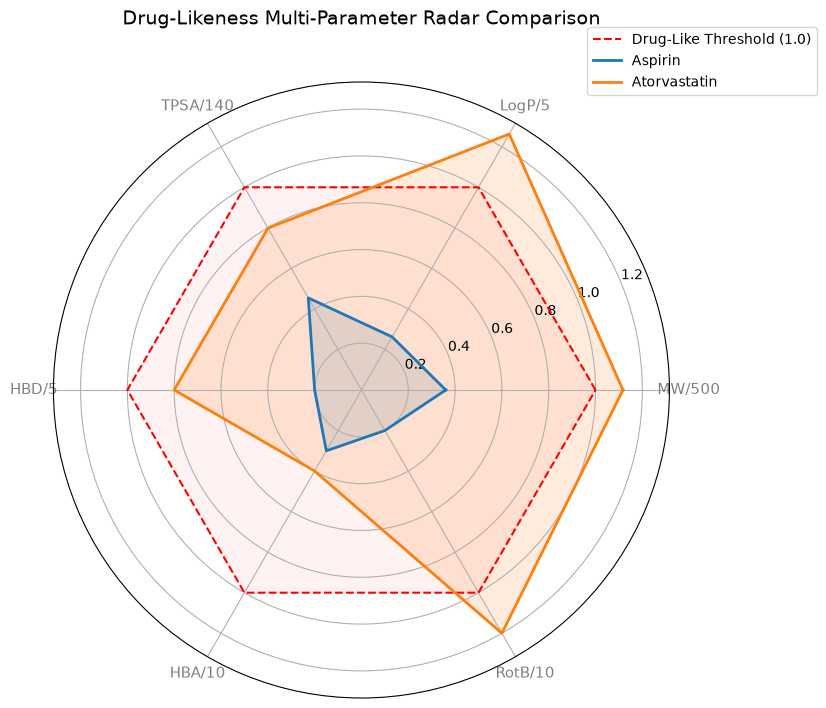

In [5]:
def plot_drug_likeness_radar(molecules_dict):
    categories = ['MW/500', 'LogP/5', 'TPSA/140', 'HBD/5', 'HBA/10', 'RotB/10']
    N = len(categories)
    
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    plt.xticks(angles[:-1], categories, color='grey', size=11)
    
    # Draw reference boundary for ideal drug-likeness (value <= 1.0)
    ideal = [1.0] * N
    ideal += ideal[:1]
    ax.plot(angles, ideal, color='red', linestyle='--', linewidth=1.5, label='Drug-Like Threshold (1.0)')
    ax.fill(angles, ideal, color='red', alpha=0.05)
    
    for name, mol in molecules_dict.items():
        mw = Descriptors.MolWt(mol) / 500.0
        logp = max(0, Descriptors.MolLogP(mol)) / 5.0
        tpsa = Descriptors.TPSA(mol) / 140.0
        hbd = Descriptors.NumHDonors(mol) / 5.0
        hba = Descriptors.NumHAcceptors(mol) / 10.0
        rot = Descriptors.NumRotatableBonds(mol) / 10.0
        
        values = [mw, logp, tpsa, hbd, hba, rot]
        values += values[:1]
        
        ax.plot(angles, values, linewidth=2, label=name)
        ax.fill(angles, values, alpha=0.15)
        
    plt.title("Drug-Likeness Multi-Parameter Radar Comparison", size=14, y=1.08)
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
    plt.show()

# Compare Aspirin vs Atorvastatin
plot_drug_likeness_radar({
    "Aspirin": aspirin,
    "Atorvastatin": atorvastatin
})

## 5. 🎯 Video Hands-On Challenge & Solution
### Problem:
Given a small virtual library of 4 candidate compounds:
1. Check Lipinski compliance (violations $\le 1$).
2. Check Veber compliance.
3. Check PAINS / Brenk structural alerts.
4. Output a summary decision table: `"PASS"` or `"REJECT"`.
5. Display passing molecules in a grid.

In [6]:
library = {
    "Candidate_A": "Cc1ccc(cc1)C(=O)Nc2ccc(cc2)C(=O)O",
    "Candidate_B": "O=C1NC(=S)SC1=Cc2ccc(O)c(O)c2",       # PAINS Rhodanine + Catechol
    "Candidate_C": "COc1cc2ncnc(Nc3cccc(c3)Cl)c2cc1OC",   # Kinase inhibitor core
    "Candidate_D": "CCCCCCCCCCCCCCC(=O)O"                 # Palmitic acid (high LogP/RotB)
}

screening_results = []
passing_mols = []
passing_legends = []

for name, smi in library.items():
    mol = Chem.MolFromSmiles(smi)
    lip = calculate_lipinski(mol)
    veb = check_veber_rules(mol)
    has_alert = len(catalog.GetMatches(mol)) > 0
    
    passes = lip["Ro5_Pass"] and veb["Veber_Pass"] and (not has_alert)
    status = "PASS" if passes else "REJECT"
    
    screening_results.append({
        "Compound": name,
        "MW": lip["MW"],
        "LogP": lip["LogP"],
        "Ro5_Violations": lip["Ro5_Violations"],
        "Veber_Pass": veb["Veber_Pass"],
        "Alert_Found": has_alert,
        "Status": status
    })
    
    if passes:
        passing_mols.append(mol)
        passing_legends.append(f"{name} (PASSED)")

df_screen = pd.DataFrame(screening_results)
print("=== 🧪 VIRTUAL SCREENING SCORECARD ===")
display(df_screen)

if passing_mols:
    Draw.MolsToGridImage(passing_mols, legends=passing_legends, molsPerRow=2, subImgSize=(300, 200))

=== 🧪 VIRTUAL SCREENING SCORECARD ===


,Compound,MW,LogP,Ro5_Violations,Veber_Pass,Alert_Found,Status
0,Candidate_A,255.27,2.95,0,True,False,PASS
1,Candidate_B,253.30,1.59,0,True,True,REJECT
2,Candidate_C,315.76,4.04,0,True,False,PASS
3,Candidate_D,242.40,5.16,1,False,True,REJECT


## 6. Summary & Key Takeaways
* **Lipinski Rule of 5:** Guides oral druggability based on size, lipophilicity, and H-bonding.
* **Veber's Rules:** Focuses on flexibility (rotatable bonds $\le 10$) and polarity (TPSA $\le 140\text{ Å}^2$).
* **`FilterCatalog`:** Automated detection of PAINS false positives and Brenk reactive groups.
* In early virtual screening, combining Lipinski + Veber + PAINS filters weeds out $70\%+ $ of untreatable or misleading hits.

**Next Up in Video 07:** **Molecular Fingerprints Deep Dive** — Morgan / ECFP, MACCS keys, and converting structures into machine-learning bit vectors!